In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline

In [2]:
df = pd.read_csv("scotch_review.csv")

In [4]:
df.head()

,Unnamed: 0,name,category,review.point,price,currency,description
0,1,"Johnnie Walker Blue Label, 40%",Blended Scotch Whisky,97,225,$,"Magnificently powerful and intense. Caramels, ..."
1,2,"Black Bowmore, 1964 vintage, 42 year old, 40.5%",Single Malt Scotch,97,4500.00,$,What impresses me most is how this whisky evol...
2,3,"Bowmore 46 year old (distilled 1964), 42.9%",Single Malt Scotch,97,13500.00,$,There have been some legendary Bowmores from t...
3,4,"Compass Box The General, 53.4%",Blended Malt Scotch Whisky,96,325,$,With a name inspired by a 1926 Buster Keaton m...
4,5,"Chivas Regal Ultis, 40%",Blended Malt Scotch Whisky,96,160,$,"Captivating, enticing, and wonderfully charmin..."


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2247 entries, 0 to 2246
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0    2247 non-null   int64 
 1   name          2247 non-null   object
 2   category      2247 non-null   object
 3   review.point  2247 non-null   int64 
 4   price         2247 non-null   object
 5   currency      2247 non-null   object
 6   description   2247 non-null   object
dtypes: int64(2), object(5)
memory usage: 123.0+ KB


In [6]:
df.drop("Unnamed: 0", axis = 1, inplace = True)

In [7]:
df.drop("currency", axis=1, inplace=True)

In [8]:
df = df.dropna(subset=['price'])

In [12]:
def get_age(name):
    match = re.search(r'(\d+)\s*(year|yo|years|y\.o)', str(name), re.IGNORECASE)

    if match:
        return int(match.group(1))
    else:
        return None

In [13]:
df = df.copy()

In [17]:
df['age'] = df['name'].apply(get_age)

In [18]:
df[df.isnull().any(axis=1)]

,name,category,review.point,price,description,age
0,"Johnnie Walker Blue Label, 40%",Blended Scotch Whisky,97,225,"Magnificently powerful and intense. Caramels, ...",NaN
3,"Compass Box The General, 53.4%",Blended Malt Scotch Whisky,96,325,With a name inspired by a 1926 Buster Keaton m...,NaN
4,"Chivas Regal Ultis, 40%",Blended Malt Scotch Whisky,96,160,"Captivating, enticing, and wonderfully charmin...",NaN
5,"Ardbeg Corryvreckan, 57.1%",Single Malt Scotch,96,85.00,"Powerful, muscular, well-textured, and invigor...",NaN
6,"Gold Bowmore, 1964 vintage, 42.4%",Single Malt Scotch,96,6250.00,Deep gold color. Surprisingly lively on the no...,NaN
...,...,...,...,...,...,...
2231,"MacNaMara Blended, 40%",Blended Scotch Whisky,76,35,This amber-colored blend from the Gaelic Whisk...,NaN
2232,"Robert Burns Single Malt, 40%",Single Malt Scotch,75,40.00,This Robert Burns World Federation Arran Singl...,NaN
2235,"Benromach Organic, 43%",Single Malt Scotch,74,75.00,Huge oak impact for such a young whisky. Fresh...,NaN
2239,"Benromach Origins, Batch #1, 1999 vintage, 50%",Single Malt Scotch,72,85.00,Origins is Benromach’s new program to highligh...,NaN


In [19]:
df = df.dropna(subset=['age'])

In [20]:
df

,name,category,review.point,price,description,age
1,"Black Bowmore, 1964 vintage, 42 year old, 40.5%",Single Malt Scotch,97,4500.00,What impresses me most is how this whisky evol...,42.0
2,"Bowmore 46 year old (distilled 1964), 42.9%",Single Malt Scotch,97,13500.00,There have been some legendary Bowmores from t...,46.0
7,"Bowmore, 40 year old, 44.8%",Single Malt Scotch,96,11000.00,"Definitely showing its age, but not in a bad w...",40.0
8,"The Dalmore, 50 year old, 52.8%",Single Malt Scotch,96,1500.00,The Dalmore is one of a handful of whiskies th...,50.0
11,"Macallan 1976 Vintage, 29 year old, cask #1135...",Single Malt Scotch,96,1500.00,Classic sherry cask-aged Macallan. Antique amb...,29.0
...,...,...,...,...,...,...
2242,"Duncan Taylor (distilled at Cameronbridge), Ca...",Grain Scotch Whisky,72,125.00,"Its best attributes are vanilla, toasted cocon...",28.0
2243,Distillery Select 'Craiglodge' (distilled at L...,Single Malt Scotch,71,60.00,"Aged in a sherry cask, which adds sweet notes ...",8.0
2244,"Edradour Barolo Finish, 11 year old, 57.1%",Single Malt Scotch,70,80.00,"Earthy, fleshy notes with brooding grape notes...",11.0
2245,"Highland Park, Cask #7380, 1981 vintage, 25 ye...",Single Malt Scotch,70,225.00,"The sherry is very dominant and cloying, which...",25.0


In [21]:
df = df.reset_index(drop=True)

In [22]:
df[df['name'].str.contains("Macallan", case=False)]

,name,category,review.point,price,description,age
4,"Macallan 1976 Vintage, 29 year old, cask #1135...",Single Malt Scotch,96,1500.00,Classic sherry cask-aged Macallan. Antique amb...,29.0
40,"The Macallan Fine Oak, 17 year old, 43%",Single Malt Scotch,94,120.00,Another of the Fine Oak series (aged in both b...,17.0
73,"The Macallan, 50 year old, 43%",Single Malt Scotch,93,3500.00,Amber-chestnut color. Aromas are very mature a...,50.0
93,That Boutique-y Whisky Company (distilled at M...,Single Malt Scotch,93,560,This has the poise and physique of a classic s...,29.0
131,"The Macallan, 15 year old, 43%",Single Malt Scotch,92,52.00,"Solid amber color. Flavors are seamless, silky...",15.0
132,"The Macallan Fine Oak, 15 year old, 43%",Single Malt Scotch,92,65.00,This is my favorite of the three. For about $2...,15.0
133,"Macallan 18 year old Sherry Oak 2017 Edition, 43%",Single Malt Scotch,92,294,The latest annual limited release is classic a...,18.0
181,"Macallan Sherry Oak 18 year old, 43%",Single Malt Scotch,91,118.00,"Macallan’s 18 year old expression is, for me, ...",18.0
277,Gordon & MacPhail (distilled at Macallan) 1970...,Single Malt Scotch,90,700.00,On more familiar ground with this G&M bottling...,41.0
278,Adelphi (distilled at Macallan) 14 year old 19...,Single Malt Scotch,90,117.00,Here is Macallan in full-blown masculine mode....,14.0


In [23]:
df.corr(numeric_only=True)

,review.point,age
review.point,1.000000,0.360279
age,0.360279,1.000000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1228 non-null   object 
 1   category      1228 non-null   object 
 2   review.point  1228 non-null   int64  
 3   price         1228 non-null   object 
 4   description   1228 non-null   object 
 5   age           1228 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 57.7+ KB


In [25]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df.corr(numeric_only=True)

,review.point,price,age
review.point,1.000000,0.168207,0.360279
price,0.168207,1.000000,0.423427
age,0.360279,0.423427,1.000000


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1228 entries, 0 to 1227
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          1228 non-null   object 
 1   category      1228 non-null   object 
 2   review.point  1228 non-null   int64  
 3   price         1215 non-null   float64
 4   description   1228 non-null   object 
 5   age           1228 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 57.7+ KB


<Axes: >

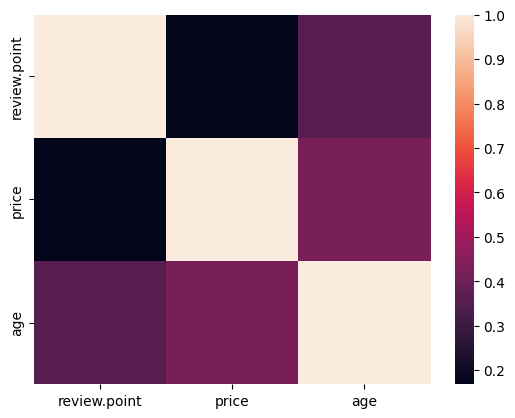

In [27]:
sns.heatmap(df.corr(numeric_only=True))

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Lasso, Ridge, ElasticNet, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import LabelEncoder

In [49]:
X = df.drop('price', axis=1)
y = df["price"]

In [51]:
X.head()

,name,category,review.point,description,age
0,"Black Bowmore, 1964 vintage, 42 year old, 40.5%",Single Malt Scotch,97,What impresses me most is how this whisky evol...,42.0
1,"Bowmore 46 year old (distilled 1964), 42.9%",Single Malt Scotch,97,There have been some legendary Bowmores from t...,46.0
2,"Bowmore, 40 year old, 44.8%",Single Malt Scotch,96,"Definitely showing its age, but not in a bad w...",40.0
3,"The Dalmore, 50 year old, 52.8%",Single Malt Scotch,96,The Dalmore is one of a handful of whiskies th...,50.0
4,"Macallan 1976 Vintage, 29 year old, cask #1135...",Single Malt Scotch,96,Classic sherry cask-aged Macallan. Antique amb...,29.0


In [52]:
X_train.head()

,name,category,review.point,description,age
87,"Cutty Sark, 25 year old, 45.7%",Blended Scotch Whisky,93,Well-structured and masculine with its rich ma...,25.0
54,Brora 37 year old (Diageo Special Releases 201...,Single Malt Scotch,93,"An old Special Releases favorite, this is the ...",37.0
89,"Convalmore 1977 28 year old, 57.9%",Single Malt Scotch,93,"OK, confession time. This remains one of my fa...",28.0
608,Springbank 14 year old Amontillado Cask (#305)...,Single Malt Scotch,87,A round of single cask Springers matured compl...,14.0
718,"Mortlach 25 year old, 43.4%",Single Malt Scotch,86,The richest of the quartet. Super-dense with a...,25.0


In [53]:
X_train.corr(numeric_only=True)

,review.point,age
review.point,1.000000,0.377601
age,0.377601,1.000000


In [64]:
def correlation_for_dropping(df, threshold):
    columns_to_drop = set()
    corr = df.corr(numeric_only=True) 
    
    for i in range(len(corr.columns)):
        for j in range(i):
            if abs(corr.iloc[i,j]) > threshold:
                columns_to_drop.add(corr.columns[i])
    return columns_to_drop

In [65]:
#correlation_for_dropping(X_train,0.95)

In [66]:
df[df['name'].str.contains("Cutty Sark, 25 year old, 45.7%", case=False)]

,name,category,review.point,price,description,age
87,"Cutty Sark, 25 year old, 45.7%",Blended Scotch Whisky,93,170.0,Well-structured and masculine with its rich ma...,25.0


In [67]:
X = df.select_dtypes(include=['float64', 'int64'])

In [68]:
if "price" in X.columns:
    X = X.drop("price", axis=1)

In [69]:
print("X sütunları:", X.columns)

X sütunları: Index(['review.point', 'age'], dtype='object')


In [70]:
df_encoded = df.copy()

In [71]:
le = LabelEncoder()

In [72]:
df_encoded['category_code'] = le.fit_transform(df_encoded['category'])

In [73]:
df_encoded = pd.get_dummies(df, columns=['category'], drop_first=True)

In [77]:
correlation_for_dropping(X_train, 0.85)

set()

In [81]:
scaler = StandardScaler()

In [88]:
y_train = pd.to_numeric(y_train, errors='coerce')
print(y_train.dtype) 

float64


In [84]:
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

In [85]:
X_train_scaled_df.head()

,review.point,age
0,1.506679,0.393266
1,1.506679,1.599922
2,1.506679,0.694930
3,0.065462,-0.712836
4,-0.174740,0.393266


In [92]:
df_clean = df.dropna(subset=['price', 'review.point', 'age'])
X = df_clean.select_dtypes(include=['float64', 'int64']).drop('price', axis=1)
y = df_clean['price']

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
X_train_scaled = scaler.fit_transform(X_train)

In [97]:
X_test_scaled = scaler.transform(X_test)

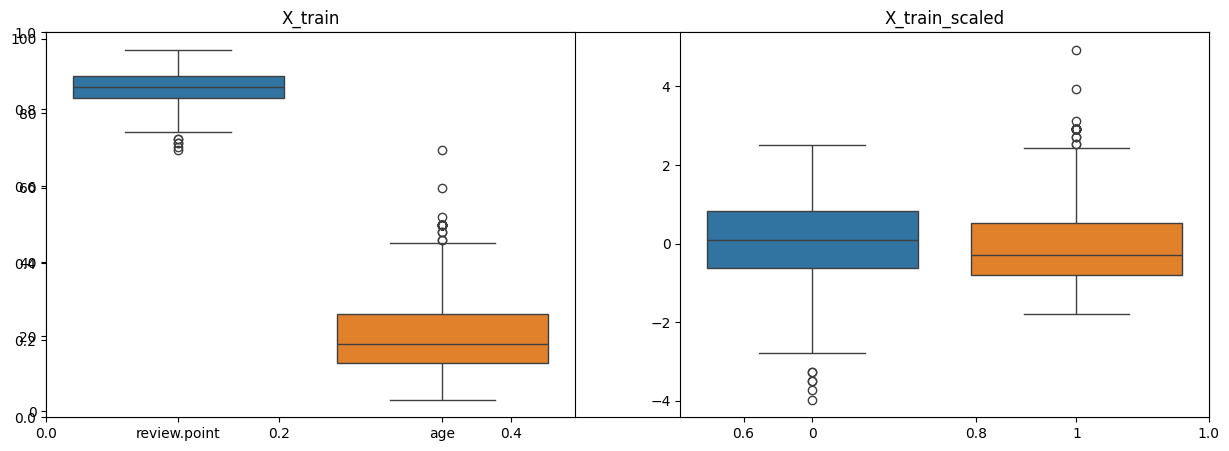

In [98]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)
plt.title("X_train")

plt.subplot(1,2,2)
sns.boxplot(data = X_train_scaled)
plt.title("X_train_scaled")
plt.show()

Mean Absolute Error:  640.8632823761922
Mean Squared Error:  1935669.1405271885
R2 Score:  0.21922481694896168


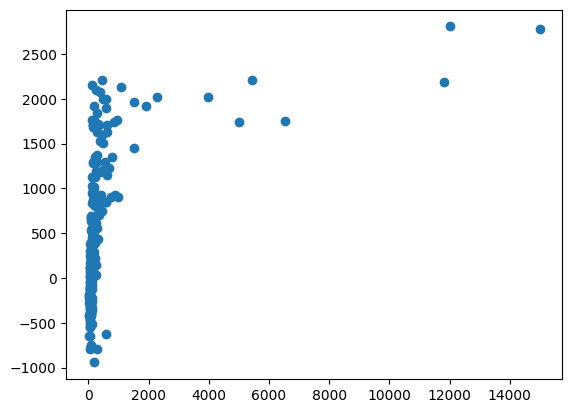

In [102]:
linear = LinearRegression()
linear.fit(X_train_scaled, y_train)
y_pred = linear.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  640.2088409862213
Mean Squared Error:  1935224.1734509321
R2 Score:  0.21940429971445186


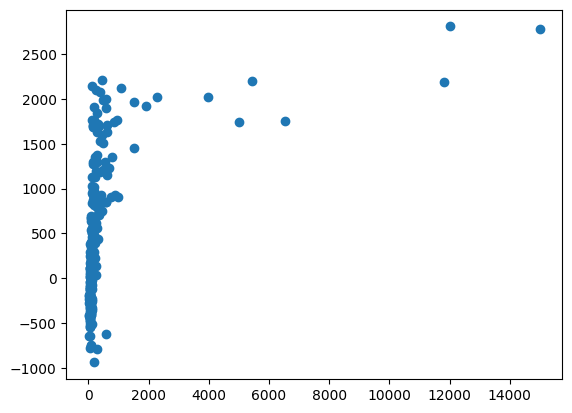

In [103]:
lasso = Lasso()
lasso.fit(X_train_scaled, y_train)
y_pred = lasso.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  640.5146387576152
Mean Squared Error:  1935780.7493574258
R2 Score:  0.21917979819909672


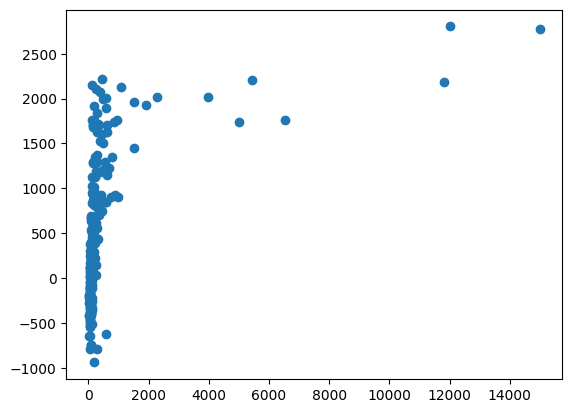

In [104]:
ridge = Ridge()
ridge.fit(X_train_scaled, y_train)
y_pred = ridge.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  538.3225083795153
Mean Squared Error:  2009758.716277383
R2 Score:  0.1893399048752088


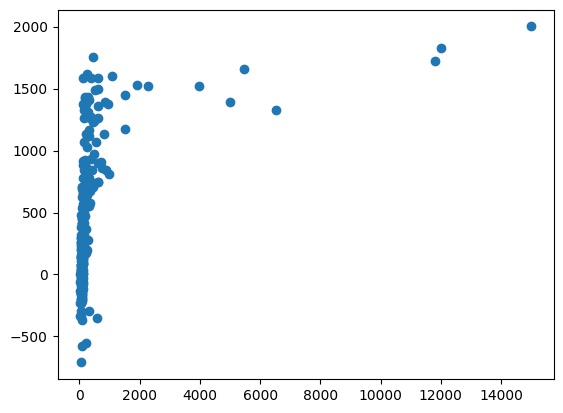

In [105]:
elastic = ElasticNet()
elastic.fit(X_train_scaled, y_train)
y_pred = elastic.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean Absolute Error:  640.3265340475906
Mean Squared Error:  1935304.6544254841
R2 Score:  0.21937183675561123


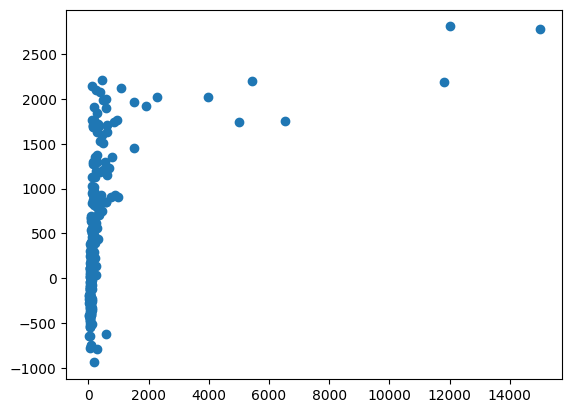

In [106]:
lassocv = LassoCV(cv = 5)
lassocv.fit(X_train_scaled, y_train)
y_pred = lassocv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean Absolute Error: ",mae)
print("Mean Squared Error: ",mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

In [107]:
lassocv.alphas_

array([820.67174646, 765.36121745, 713.77843296, 665.67215552,
       620.80808016, 578.96769333, 539.94720854, 503.55657382,
       469.61854609, 437.96782784, 408.45026207, 380.92208145,
       355.24920806, 331.30660041, 308.97764439, 288.15358527,
       268.73299804, 250.62129339, 233.73025701, 217.97761996,
       203.28665792, 189.58581755, 176.80836797, 164.89207573,
       153.7789017 , 143.4147184 , 133.74904638, 124.73480829,
       116.32809969, 108.4879751 , 101.17624868,  94.35730814,
        87.99794138,  82.06717465,  76.53612174,  71.3778433 ,
        66.56721555,  62.08080802,  57.89676933,  53.99472085,
        50.35565738,  46.96185461,  43.79678278,  40.84502621,
        38.09220814,  35.52492081,  33.13066004,  30.89776444,
        28.81535853,  26.8732998 ,  25.06212934,  23.3730257 ,
        21.797762  ,  20.32866579,  18.95858176,  17.6808368 ,
        16.48920757,  15.37789017,  14.34147184,  13.37490464,
        12.47348083,  11.63280997,  10.84879751,  10.11

In [108]:
lassocv.alpha_

np.float64(0.8206717464645753)

Mean absolute Error:  637.4039234614628
Mean Squared Error:  1936808.451098163
R2 Score:  0.21876526247191797


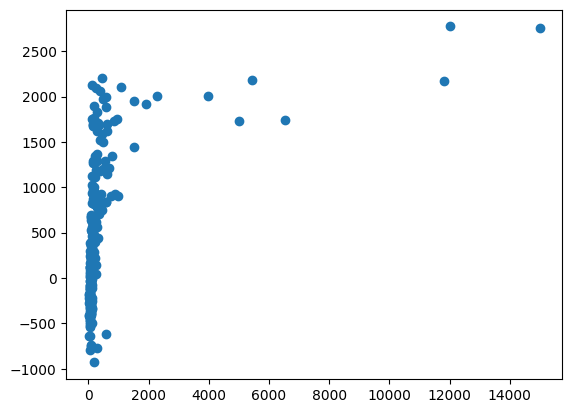

In [109]:
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)
y_pred = ridgecv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

Mean absolute Error:  513.9405630762755
Mean Squared Error:  2055045.452751353
R2 Score:  0.17107296078856704


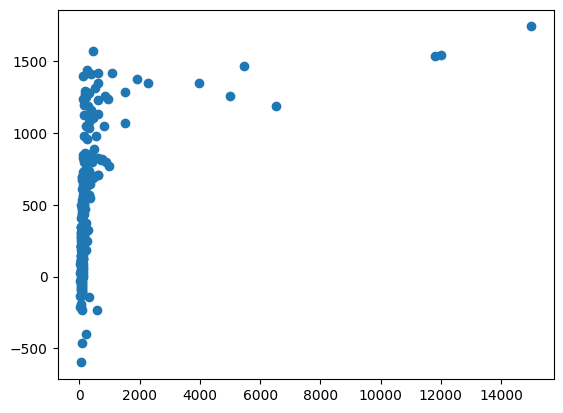

In [110]:
elasticnetcv = ElasticNetCV(cv=5)
elasticnetcv.fit(X_train_scaled, y_train)
y_pred = elasticnetcv.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print("Mean absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("R2 Score: ", score)
plt.scatter(y_test, y_pred)
plt.show()

In [111]:
residuals = y_test - y_pred

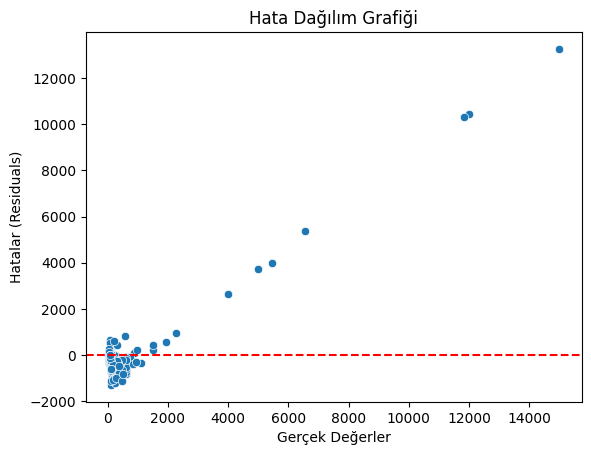

In [112]:
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Gerçek Değerler")
plt.ylabel("Hatalar (Residuals)")
plt.title("Hata Dağılım Grafiği")
plt.show()